## Data Loading

In [15]:
import pandas as pd

train = pd.read_csv("../data/raw/train_FD001.txt", delim_whitespace=True, header=None)
test = pd.read_csv("../data/raw/test_FD001.txt", delim_whitespace=True, header=None)
rul = pd.read_csv("../data/raw/RUL_FD001.txt", header=None)

C:\Users\KIIT\AppData\Local\Temp\ipykernel_18924\2148774215.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  train = pd.read_csv("../data/raw/train_FD001.txt", delim_whitespace=True, header=None)
C:\Users\KIIT\AppData\Local\Temp\ipykernel_18924\2148774215.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  test = pd.read_csv("../data/raw/test_FD001.txt", delim_whitespace=True, header=None)


In [27]:
import pandas as pd

columns = ['engine_id', 'cycle', 'op1', 'op2', 'op3'] + [f'sensor_{i}' for i in range(1,22)]

train = pd.read_csv("../data/raw/train_FD001.txt", sep=r"\s+", names=columns, header=None)

test = pd.read_csv("../data/raw/test_FD001.txt", sep=r"\s+", names=columns, header=None)

rul = pd.read_csv("../data/raw/RUL_FD001.txt", header=None)

In [28]:
train.head()

,engine_id,cycle,op1,op2,op3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Creating RUL(Runtime Until Failure) for Training Data
### RUL = max(cycle) - current_cycle

In [29]:
# Calculate max cycle per engine using transform (NO MERGE)
train['max_cycle'] = train.groupby('engine_id')['cycle'].transform('max')

# Create RUL
train['RUL'] = train['max_cycle'] - train['cycle']

# Drop max_cycle column (no longer needed)
train.drop(columns=['max_cycle'], inplace=True)

# Cap RUL at 125
train['RUL'] = train['RUL'].clip(upper=125)

train.head()
# Sanity Check: Display last row should have RUL = 0
train[train['engine_id'] == 1].tail()

,engine_id,cycle,op1,op2,op3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588,4
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127,3
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675,2
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295,1
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,2388.32,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649,0


## EDA (Exploratory Data Analysis)

#### Step1: Check dataset shape and columns

In [30]:
print("Train shape:", train.shape)

Train shape: (20631, 27)


#### Step2: Identify Constant Sensors

In [31]:
sensor_cols = [col for col in train.columns if "sensor" in col]
train[sensor_cols].nunique().sort_values()

sensor_1        1
sensor_5        1
sensor_16       1
sensor_10       1
sensor_19       1
sensor_18       1
sensor_6        2
sensor_17      13
sensor_8       53
sensor_13      56
sensor_20     120
sensor_11     159
sensor_2      310
sensor_12     427
sensor_7      513
sensor_15    1918
sensor_3     3012
sensor_4     4051
sensor_21    4745
sensor_14    6078
sensor_9     6403
dtype: int64

#### Step3: Remove constant sensors

In [32]:
constant_sensors = [col for col in sensor_cols if train[col].nunique() == 1]
train.drop(columns=constant_sensors, inplace=True)
constant_sensors

['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

#### Step4: Check Correlations with RUL

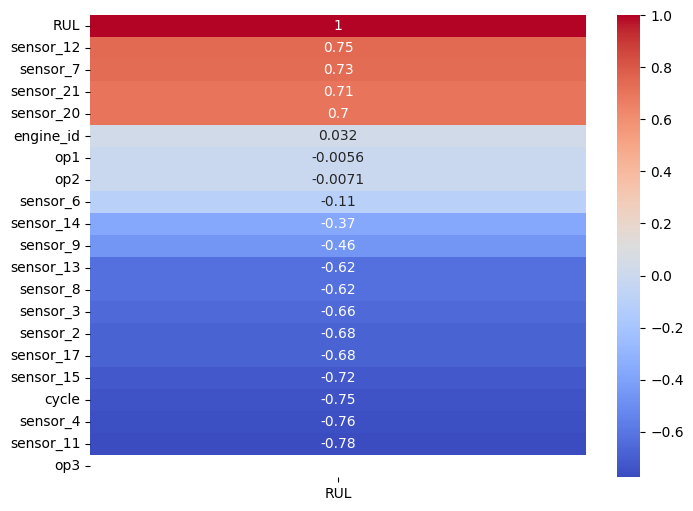

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = train.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr[['RUL']].sort_values(by='RUL', ascending=False),
            annot=True,
            cmap='coolwarm')
plt.show()

#### Step5: Visualizing Sensor Degradation

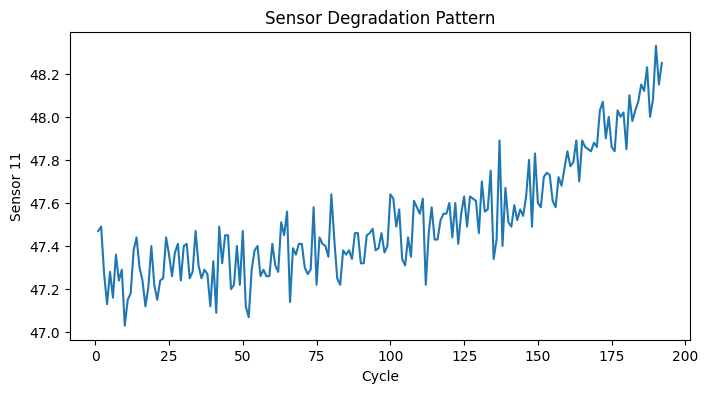

In [34]:
engine1 = train[train['engine_id'] == 1]

plt.figure(figsize=(8,4))
plt.plot(engine1['cycle'], engine1['sensor_11'])
plt.xlabel("Cycle")
plt.ylabel("Sensor 11")
plt.title("Sensor Degradation Pattern")
plt.show()

#### Checking shape and sensors

In [35]:
constant_sensors
train.shape
train.columns

Index(['engine_id', 'cycle', 'op1', 'op2', 'op3', 'sensor_2', 'sensor_3',
       'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
       'sensor_20', 'sensor_21', 'RUL'],
      dtype='object')

#### Step6: Confirming number of unique engine_ids and Checking RUL Range

In [36]:
train['engine_id'].nunique()

train['RUL'].describe()

count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64

#### Step7: Visualize Engine Degradation

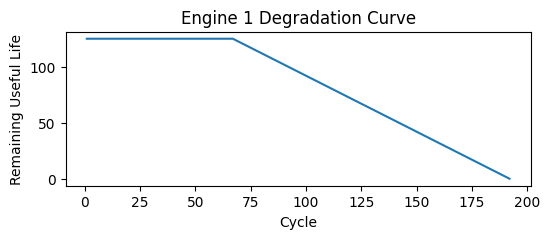

In [37]:
import matplotlib.pyplot as plt

engine = train[train['engine_id'] == 1]

plt.figure(figsize=(6,2))
plt.plot(engine['cycle'], engine['RUL'])
plt.xlabel("Cycle")
plt.ylabel("Remaining Useful Life")
plt.title("Engine 1 Degradation Curve")
plt.show()

It shows a descending curve

That's exactly what predictive maintenance models learn.

So, right now our model only sees:

**Sensor value at time t**

But engines fail due to patterns over time, not single readings.
So we will create time-series features like:
1. rolling_mean
2. rolling_std
3. sensor_change_rate
4. sensor_delta

This step will help to double model performance.

In [38]:
train.to_csv("../data/processed/processed_train.csv", index=False)

In [39]:
train.head()
train.columns

Index(['engine_id', 'cycle', 'op1', 'op2', 'op3', 'sensor_2', 'sensor_3',
       'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
       'sensor_20', 'sensor_21', 'RUL'],
      dtype='object')